# 03 — Walk-Forward Backtesting

Evaluate the Elo model on each World Cup (2002–2022) using only data available before that tournament.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, brier_score_loss
import sys
sys.path.append('..')
from src.elo import EloModel
from src.backtest import walk_forward_wc

%matplotlib inline

In [2]:
df = pd.read_csv('../data/processed/matches_competitive.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

## Walk-forward evaluation

For each World Cup year: train Elo on all data before the tournament, predict each match, score.

In [3]:
wc_years = [2002, 2006, 2010, 2014, 2018, 2022]
results = walk_forward_wc(df, wc_years, k=32, home_advantage=100)
results

,year,n_matches,log_loss,accuracy,raw
0,2002,64,0.761684,0.390625,home_win_prob home_win 0 0.779541 ...
1,2006,64,0.707480,0.515625,home_win_prob home_win 0 0.597700 ...
2,2010,64,0.663788,0.625000,home_win_prob home_win 0 0.363540 ...
3,2014,64,0.725877,0.484375,home_win_prob home_win 0 0.804322 ...
4,2018,64,0.689267,0.562500,home_win_prob home_win 0 0.474017 ...
5,2022,64,0.684787,0.578125,home_win_prob home_win 0 0.784888 ...


## Metrics per tournament

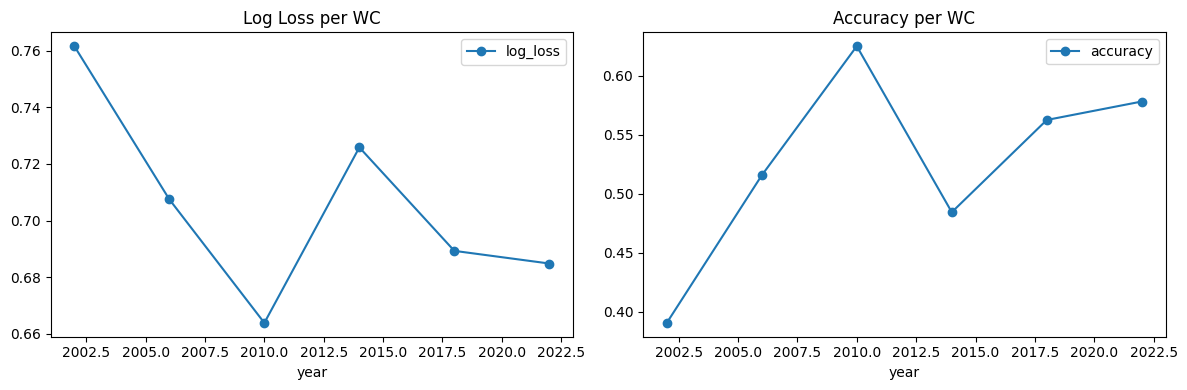

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results.plot(x='year', y='log_loss', ax=axes[0], marker='o', title='Log Loss per WC')
results.plot(x='year', y='accuracy', ax=axes[1], marker='o', title='Accuracy per WC')
plt.tight_layout()

## Calibration check

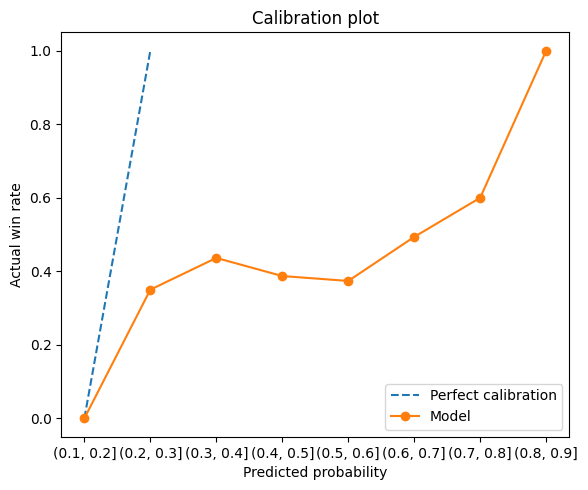

In [5]:
# Are predicted probabilities well-calibrated?
# Bin predictions and compare to actual win rates
all_preds = pd.concat(results['raw'].tolist(), ignore_index=True)
bins = np.linspace(0, 1, 11)
all_preds['bin'] = pd.cut(all_preds['home_win_prob'], bins)
cal = all_preds.groupby('bin')['home_win'].mean()

plt.figure(figsize=(6, 5))
plt.plot([0,1],[0,1],'--', label='Perfect calibration')
cal.plot(marker='o', label='Model')
plt.xlabel('Predicted probability')
plt.ylabel('Actual win rate')
plt.title('Calibration plot')
plt.legend()
plt.tight_layout()